# Backtest intraday strategies on IG NASDAQ 100 CFD 10-minute candles (`quant-market-data`)

Loads IG's **US Tech 100 Cash (A$1)** 10-minute candles (epic
`IX.D.NASDAQ.IFA.IP`) from the separate `quant-market-data` repo's Postgres
database - provider `ig` / symbol `NASDAQ100`, i.e. `instrument_id = 1` in its
`candles_minute_10` table - runs an intraday strategy through the same
backtester as `08_ig_nasdaq_daily_backtest_db.ipynb`
(`trading_toolkit/ig_backtest.py`), and reports: a metrics table (**initial
funding -> final funding**), the trade list, price / equity / drawdown charts,
P&L per trading day, P&L by time of day, and a comparison of every intraday
strategy.

**Strategies (`ig_quant_trading.strategies`, imported below as `st`)** -
from the sibling ig-quant-trading repo that trades them live, installed here
editable, so what you backtest is exactly what it runs. Each bar they say BUY
(be long), SELL (be short) or HOLD (keep what's open):

| strategy | idea |
| --- | --- |
| `EMAStrategy(fast_period, slow_period)` | BUY while the fast EMA is above the slow EMA, SELL while below |
| `RSIStrategy(period, overbought, oversold, trend)` | BUY when RSI is at or below `oversold`, SELL at or above `overbought` (with `trend`: only with the `trend`-bar SMA) |
| `BollingerBandsStrategy(period, num_std)` | BUY below the lower Bollinger band, SELL above the upper |
| `DonchianBreakoutStrategy(period)` | BUY a break of the `period`-bar high, SELL a break of the low |
| `VWAPTrendStrategy(band_bps)` | in the US session, BUY above the session VWAP, SELL below |
| `OpeningRangeBreakoutStrategy(range_minutes)` | the first break of the first N minutes' high (BUY) or low (SELL) sets the day's side |
| `SessionFilter(inner)` | wraps any strategy: only in the market 09:30-16:00 New York time, flat overnight |

Session times are New York local time (daylight saving handled); candle
timestamps are UTC. `SessionFilter`, `VWAPTrendStrategy` and `OpeningRangeBreakoutStrategy`
carry that session, and the engine closes them out by 16:00 New York - live,
set `ig_quant_trading`'s `TRADING_SESSIONS_UTC` to match (it's fixed UTC, so
move it by an hour when US clocks change).

**Engine** - fixed-size CFD position: `INITIAL_FUNDING` (default **20,000
AUD**), `POINT_VALUE` (**1 AUD/point**), `SIZE` contracts long or short - an opposite signal
closes and reverses the position, as `ig_quant_trading` does live. Fills at
the **next bar's open** (no look-ahead), a flat `fee_bps` per entry and exit.
No overnight funding, slippage or margin calls.

**Read the results with care** - the database holds only a few weeks of
10-minute history, so CAGR, Sharpe and volatility are annualised from a very
short sample and will look extreme. Treat the P&L, drawdown and trade stats as
the meaningful numbers, and don't pick a strategy on a few weeks' results.

**Prerequisite:** the `trading_toolkit` package installed (`uv sync --extra
dev`) *and* the `quant-market-data` Postgres database running and seeded with
IG 10-minute history, with `PGHOST`/`PGPORT`/`PGUSER`/`PGPASSWORD`/`PGDATABASE`
set in this repo's `.env` (see `.env.sample`).

## 1. Config, window & strategy

`RESOLUTION = "MINUTE_10"` reads `candles_minute_10`. Set `START` / `END` (UTC,
e.g. `"2026-09-07"` or `"2026-09-07 13:30"`) to bound the backtest; either may
be `None`. `FEE_BPS = None` sets the per-side cost to half the median bid/ask
spread (so a round trip costs one spread).

In [1]:
import pandas as pd

from ig_quant_trading import strategies as st

from trading_toolkit import ig_backtest as backtest
from trading_toolkit import market_db
from trading_toolkit.constants.ig_ohlc_fields import OHLCField

# quant-market-data instrument to backtest. ig/NASDAQ100 = instrument_id 1.
PROVIDER = "ig"
SYMBOL = "NASDAQ100"
RESOLUTION = "MINUTE_10"

# Backtest window (UTC, inclusive). None = all available history on that side.
START = None
END = None

# Strategy under test - see the table above, or section 9 for more examples.
strategy = st.SessionFilter(st.EMAStrategy(fast_period=12, slow_period=48))

# Account model.
INITIAL_FUNDING = 20_000.0  # starting balance, account currency
POINT_VALUE = 1.0           # A$1 contract: 1 AUD per index point, per contract
SIZE = 1.0                  # contracts held, long or short
CURRENCY = "AUD"
FEE_BPS = None              # None = half the median bid/ask spread, per side

print(f"{PROVIDER}/{SYMBOL}  {RESOLUTION}")
print(f"window  : {START or 'earliest'}  ->  {END or 'latest'}")
print(f"strategy: {strategy.label}")
print(f"account : {INITIAL_FUNDING:,.0f} {CURRENCY}   {SIZE:g} contract(s) @ {POINT_VALUE:g} {CURRENCY}/point")

ig/NASDAQ100  MINUTE_10
window  : earliest  ->  latest
strategy: EMA 12/48 [09:30-16:00]
account : 20,000 AUD   1 contract(s) @ 1 AUD/point


## 2. Instrument & spread

Looks the instrument up and measures the close bid/ask spread across its
10-minute bars - split into the US cash session and outside it, since IG's
spread widens overnight. The fee is set from the median across all bars.

In [2]:
table = market_db.table_name_for_resolution(RESOLUTION)
conn = market_db.connect()
with conn.cursor() as cur:
    cur.execute(
        "SELECT i.id, i.provider_symbol, i.name "
        "FROM instruments i JOIN providers p ON p.id = i.provider_id "
        "WHERE p.code = %s AND i.symbol = %s",
        (PROVIDER, SYMBOL),
    )
    row = cur.fetchone()
    assert row, f"No instrument {PROVIDER}/{SYMBOL} in quant-market-data"
    instrument_id, epic, name = row
    cur.execute(
        "SELECT snapshot_time, close_ask_price - close_bid_price, "
        "(close_ask_price - close_bid_price) / close_price * 10000 "
        f"FROM {table} WHERE instrument_id = %s AND close_bid_price IS NOT NULL",
        (instrument_id,),
    )
    spread = pd.DataFrame(cur.fetchall(), columns=["time", "points", "bps"])

spread = spread.set_index(pd.to_datetime(spread["time"]))[["points", "bps"]].astype(float)
session_label = pd.Series(st.in_session(spread.index), index=spread.index).map(
    {True: "US session", False: "outside session"})

print(f"instrument_id {instrument_id}: {epic}  ({name})\n")
print(spread.groupby(session_label).median().round(2).add_prefix("median_"))

if FEE_BPS is None:
    FEE_BPS = round(spread["bps"].median() / 2, 2)
print(f"\nfee: {FEE_BPS} bps per side")

instrument_id 1: IX.D.NASDAQ.IFA.IP  (US Tech 100 Cash (A$1))

                 median_points  median_bps
US session                 1.2        0.41
outside session            2.0        0.68

fee: 0.34 bps per side


## 3. Load candles from `quant-market-data`

`market_db.load_candles` yields one flat OHLC dict per candle from the
`*_price` columns (for IG, the bid/ask mid).

In [3]:
df = pd.DataFrame(market_db.load_candles(conn, PROVIDER, SYMBOL, RESOLUTION))
conn.close()

assert not df.empty, (
    f"No candles for {PROVIDER}/{SYMBOL} / {RESOLUTION} in quant-market-data - "
    "check its Postgres DB is running and seeded with IG 10-minute history."
)

df[OHLCField.SNAPSHOT_TIME_UTC] = pd.to_datetime(df[OHLCField.SNAPSHOT_TIME_UTC])
df = df.set_index(OHLCField.SNAPSHOT_TIME_UTC).sort_index()
df = df[[OHLCField.OPEN, OHLCField.HIGH, OHLCField.LOW, OHLCField.CLOSE, OHLCField.VOLUME]]

if START:
    df = df[df.index >= pd.Timestamp(START)]
if END:
    df = df[df.index <= pd.Timestamp(END)]

assert len(df) > 100, f"Only {len(df)} bars in the window - widen START/END."
days = st.session_dates(df.index).nunique()
print(f"{len(df)} bars   {df.index[0]:%Y-%m-%d %H:%M}  ->  {df.index[-1]:%Y-%m-%d %H:%M} UTC   "
      f"({days} New York calendar days)")
df.head()

2669 bars   2026-08-31 14:00  ->  2026-09-25 07:20 UTC   (23 New York calendar days)


,open,high,low,close,volume
snapshot_time_utc,,,,,
2026-08-31 14:00:00,29384.45,29393.40,29323.15,29326.60,13879
2026-08-31 14:10:00,29327.75,29379.20,29321.05,29367.90,12354
2026-08-31 14:20:00,29367.20,29373.65,29305.55,29324.95,11042
2026-08-31 14:30:00,29323.45,29376.15,29312.15,29355.75,9363
2026-08-31 14:40:00,29354.55,29382.25,29331.10,29337.20,9343


## 4. Run the backtest

Buy & hold over the same window is shown for comparison (held around the
clock, including overnight).

In [4]:
result = backtest.run_backtest(
    df, strategy,
    initial_funding=INITIAL_FUNDING, point_value=POINT_VALUE, size=SIZE,
    fee_bps=FEE_BPS, currency=CURRENCY,
)
print(result.summary())

strategy           : EMA 12/48 [09:30-16:00]
period             : 2026-08-31 14:00 -> 2026-09-25 07:20  (2669 bars)
initial funding    : 20,000.00 AUD
final funding      : 20,333.45 AUD
profit / loss      : +333.45 AUD  (+1.67%)
buy & hold         : +1,288.00 AUD  (+6.44%)
position size      : 1 @ 1 AUD/point   (~1.47x funding at entry)
CAGR               : +27.67%
ann. volatility    : 13.74%
Sharpe (rf=0)      : 1.85
max drawdown       : -5.17%
time in market     : 25.6%  (long 14.5%, short 11.1%)
trades             : 37  (18 long, 19 short)
win rate           : 40.5%
avg / best / worst : +11.02 / +480.70 / -175.90 AUD


## 5. Trades

One row per round trip; `direction` is BUY (long) or SELL (short). `minutes_held` is `bars_held * 10`; `open = True`
marks a position still held at the end of the window.

In [5]:
trades = result.trades.copy()
if not trades.empty:
    trades["return_pct"] = trades["return_pct"].round(3)
    trades["minutes_held"] = trades["bars_held"] * 10
trades

,direction,entry_time,exit_time,entry_price,exit_price,points,pnl,return_pct,bars_held,open,minutes_held
0,SELL,2026-09-01 13:40:00,2026-09-01 20:00:00,29020.10,29073.20,-53.10,-53.10,-0.183,38,False,380
1,BUY,2026-09-02 13:40:00,2026-09-02 20:00:00,29038.70,29142.50,103.80,103.80,0.357,38,False,380
2,BUY,2026-09-03 13:40:00,2026-09-03 20:00:00,29285.00,29485.90,200.90,200.90,0.686,38,False,380
3,SELL,2026-09-04 13:40:00,2026-09-04 14:10:00,29586.40,29602.00,-15.60,-15.60,-0.053,3,False,30
4,BUY,2026-09-04 14:10:00,2026-09-04 14:20:00,29602.00,29561.10,-40.90,-40.90,-0.138,1,False,10
5,SELL,2026-09-04 14:20:00,2026-09-04 20:00:00,29561.10,29538.60,22.50,22.50,0.076,34,False,340
6,SELL,2026-09-07 13:40:00,2026-09-07 14:10:00,29578.10,29580.40,-2.30,-2.30,-0.008,3,False,30
7,BUY,2026-09-07 14:10:00,2026-09-07 15:30:00,29580.40,29548.00,-32.40,-32.40,-0.110,8,False,80
8,SELL,2026-09-07 15:30:00,2026-09-07 16:50:00,29548.00,29573.10,-25.10,-25.10,-0.085,8,False,80
9,BUY,2026-09-07 16:50:00,2026-09-07 19:20:00,29573.10,29566.30,-6.80,-6.80,-0.023,15,False,150


## 6. Charts

Price (with the strategy's EMAs or VWAP where it has them) and buy/sell
markers, the equity curve against buy & hold, and drawdown. Bars are plotted
in sequence, so weekends and the daily break don't leave gaps; ticks mark the
start of each UTC weekday, and the shaded band is the US cash session.

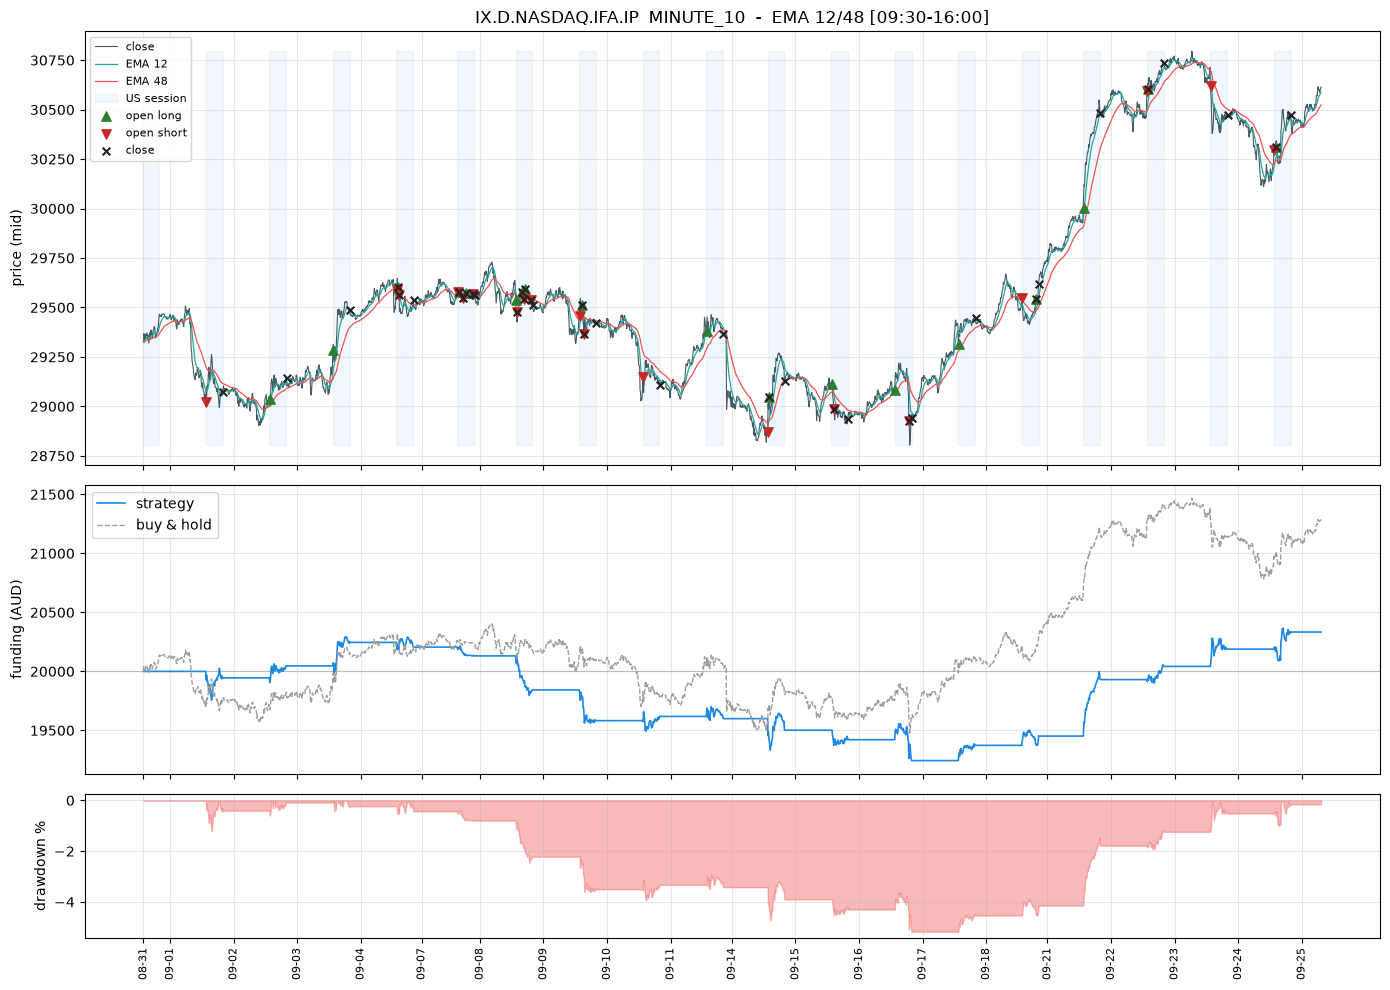

In [6]:
import matplotlib.pyplot as plt
import numpy as np

close = df[OHLCField.CLOSE]
eq = result.equity
bh = INITIAL_FUNDING + (close - close.iloc[0]) * POINT_VALUE * SIZE
dd = (eq / eq.cummax() - 1) * 100
t = result.trades
x = np.arange(len(df))
pos = pd.Series(x, index=df.index)
inner = getattr(strategy, "inner", strategy)

fig, (ax_px, ax_eq, ax_dd) = plt.subplots(
    3, 1, sharex=True, figsize=(14, 10),
    gridspec_kw={"height_ratios": [3, 2, 1]},
)

ax_px.plot(x, close, color="#455a64", lw=0.8, label="close")
if isinstance(inner, st.EMAStrategy):
    for span, colour in ((inner.fast_period, "#26a69a"), (inner.slow_period, "#ef5350")):
        ax_px.plot(x, close.ewm(span=span, adjust=False).mean(), color=colour, lw=0.9, label=f"EMA {span}")
if isinstance(inner, st.VWAPTrendStrategy):
    ax_px.plot(x, st.session_vwap(df), color="#ff9800", lw=0.9, label="session VWAP")
ax_px.fill_between(x, close.min(), close.max(), where=st.in_session(df.index),
                   color="#1e88e5", alpha=0.06, step="post", label="US session")
if not t.empty:
    for side, marker, colour, label in (("BUY", "^", "#2e7d32", "open long"),
                                        ("SELL", "v", "#c62828", "open short")):
        e = t[t["direction"] == side]
        ax_px.scatter(pos[e["entry_time"]], e["entry_price"], marker=marker, s=45, color=colour,
                      zorder=5, label=label)
    closed = t[~t["open"]]
    ax_px.scatter(pos[closed["exit_time"]], closed["exit_price"], marker="x", s=30, color="#212121",
                  zorder=6, label="close")
ax_px.set_ylabel("price (mid)")
ax_px.set_title(f"{epic}  {RESOLUTION}  -  {strategy.label}")
ax_px.legend(loc="upper left", fontsize=8)
ax_px.grid(alpha=0.3)

ax_eq.axhline(INITIAL_FUNDING, color="#bbbbbb", lw=0.8)
ax_eq.plot(x, eq, color="#1e88e5", lw=1.2, label="strategy")
ax_eq.plot(x, bh, color="#9e9e9e", lw=1, ls="--", label="buy & hold")
ax_eq.set_ylabel(f"funding ({CURRENCY})")
ax_eq.legend(loc="upper left")
ax_eq.grid(alpha=0.3)

ax_dd.fill_between(x, dd, 0, color="#ef5350", alpha=0.4)
ax_dd.set_ylabel("drawdown %")
ax_dd.grid(alpha=0.3)

first_of_day = pos.groupby(df.index.normalize()).first()
first_of_day = first_of_day[first_of_day.index.dayofweek < 5]  # skip the short Sunday-evening session
ax_dd.set_xticks(first_of_day.to_numpy())
ax_dd.set_xticklabels([d.strftime("%m-%d") for d in first_of_day.index], rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

## 7. P&L per trading day

Change in account value per New York calendar day, strategy vs. buy & hold.

In [7]:
day = st.session_dates(df.index)
daily = pd.DataFrame({
    f"strategy_{CURRENCY}": eq.diff().fillna(eq.iloc[0] - INITIAL_FUNDING).groupby(day).sum(),
    f"buy_hold_{CURRENCY}": bh.diff().fillna(0.0).groupby(day).sum(),
}).round(2)
daily.index = daily.index.date
daily.index.name = "NY date"
print(f"strategy winning days: {(daily.iloc[:, 0] > 0).sum()} / {len(daily)}")
daily

strategy winning days: 9 / 23


,strategy_AUD,buy_hold_AUD
NY date,,
2026-08-31,0.00,107.6
2026-09-01,-55.08,-435.5
2026-09-02,101.82,190.2
2026-09-03,198.90,337.3
2026-09-04,-40.03,-35.7
2026-09-06,0.00,66.5
2026-09-07,-74.55,157.5
2026-09-08,-288.25,-180.1
2026-09-09,-260.31,-137.6


## 8. P&L by time of day

Strategy P&L from each 10-minute bar, summed by the New York hour it falls in -
shows when the strategy makes and loses money.

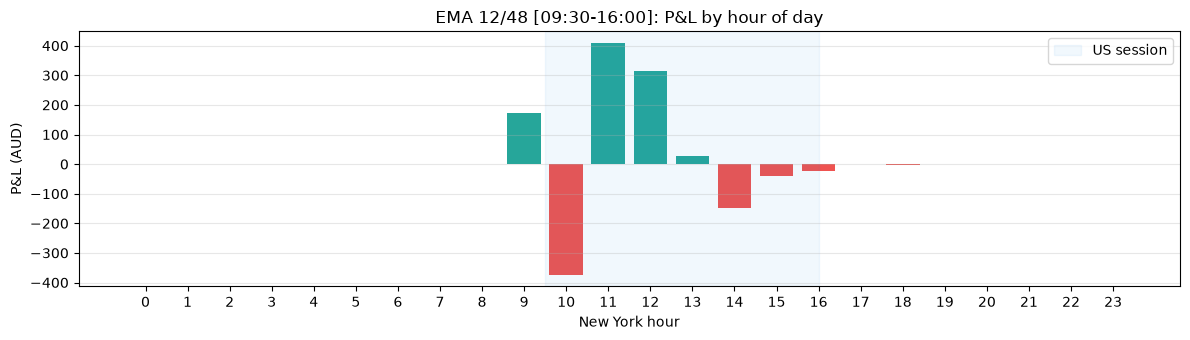

In [8]:
ny_hour = st.to_local(df.index).hour
by_hour = eq.diff().fillna(0.0).groupby(ny_hour).sum().round(2)
by_hour.index.name = "NY hour"

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(by_hour.index, by_hour, color=np.where(by_hour >= 0, "#26a69a", "#ef5350"))
ax.axvspan(9.5, 16, color="#1e88e5", alpha=0.06, label="US session")
ax.set_xticks(range(24))
ax.set_xlabel("New York hour")
ax.set_ylabel(f"P&L ({CURRENCY})")
ax.set_title(f"{strategy.label}: P&L by hour of day")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 9. Compare the intraday strategies

Same window, same costs. `[09:30-16:00]` marks a strategy wrapped in
`SessionFilter`. Edit the list to taste - but with only a few weeks of data,
expect the ranking to change as more history is loaded.

In [9]:
S = st.SessionFilter
candidates = [
    st.BuyHoldStrategy(),
    S(st.BuyHoldStrategy()),
    st.EMAStrategy(12, 48),
    S(st.EMAStrategy(12, 48)),
    S(st.EMAStrategy(6, 24)),
    st.RSIStrategy(14),
    S(st.RSIStrategy(14)),
    st.RSIStrategy(14, trend=48),
    st.BollingerBandsStrategy(20, 2.0),
    S(st.BollingerBandsStrategy(20, 2.0)),
    st.DonchianBreakoutStrategy(24),
    S(st.DonchianBreakoutStrategy(24)),
    st.VWAPTrendStrategy(),
    st.VWAPTrendStrategy(band_bps=5),
    st.OpeningRangeBreakoutStrategy(30),
    st.OpeningRangeBreakoutStrategy(60),
]

rows = []
for strat in candidates:
    s = backtest.run_backtest(
        df, strat,
        initial_funding=INITIAL_FUNDING, point_value=POINT_VALUE, size=SIZE,
        fee_bps=FEE_BPS, currency=CURRENCY,
    ).stats
    rows.append({
        "strategy": strat.label,
        f"profit_{CURRENCY}": round(s["profit"], 2),
        "return_%": round(s["total_return_pct"], 2),
        "max_dd_%": round(s["max_drawdown_pct"], 2),
        "exposure_%": round(s["exposure_pct"], 1),
        "trades": s["n_trades"],
        "win_rate_%": round(s["win_rate_pct"], 1),
        f"avg_trade_{CURRENCY}": round(s["avg_trade_pnl"], 2),
    })

pd.DataFrame(rows).set_index("strategy").sort_values(f"profit_{CURRENCY}", ascending=False)

,profit_AUD,return_%,max_dd_%,exposure_%,trades,win_rate_%,avg_trade_AUD
strategy,,,,,,,
buy & hold,1285.85,6.43,-4.54,100.0,1,100.0,1286.85
Donchian 24,1208.78,6.04,-7.87,98.7,53,39.6,24.79
EMA 12/48,1158.49,5.79,-6.46,98.2,57,29.8,22.32
buy & hold [09:30-16:00],1063.33,5.32,-2.88,26.9,19,52.6,57.97
Donchian 24 [09:30-16:00],881.92,4.41,-2.54,17.9,19,57.9,48.42
EMA 6/24 [09:30-16:00],590.20,2.95,-5.15,26.1,49,46.9,14.05
EMA 12/48 [09:30-16:00],333.45,1.67,-5.17,25.6,37,40.5,11.02
VWAP trend,276.04,1.38,-4.67,26.9,68,27.9,6.06
VWAP trend (+/-5 bps),213.18,1.07,-4.12,26.8,43,37.2,6.96
